In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
goog_data = yf.download('GOOG', start='2001-01-01', end='2018-01-01', progress=False)

# Flatten multi-level columns if present
if isinstance(goog_data.columns, pd.MultiIndex):
    goog_data.columns = goog_data.columns.get_level_values(0)

print(f"Shape: {goog_data.shape}")
goog_data.head()

Shape: (3366, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2004-08-19,2.477292,2.569134,2.369154,2.468896,897427216
2004-08-20,2.674062,2.693073,2.481242,2.493833,458857488
2004-08-23,2.700974,2.801704,2.692333,2.734304,366857939
2004-08-24,2.589133,2.755289,2.557037,2.746401,306396159
2004-08-25,2.617030,2.666409,2.564690,2.591354,184645512


In [3]:
signals = pd.DataFrame(index=goog_data.index)

short_window = 40
long_window  = 100

signals['short_ma'] = goog_data['Close'].rolling(window=short_window).mean()
signals['long_ma']  = goog_data['Close'].rolling(window=long_window).mean()

print(signals.head(110))

            short_ma   long_ma
Date                          
2004-08-19       NaN       NaN
2004-08-20       NaN       NaN
2004-08-23       NaN       NaN
2004-08-24       NaN       NaN
2004-08-25       NaN       NaN
...              ...       ...
2005-01-19  4.568903  3.946801
2005-01-20  4.586692  3.968470
2005-01-21  4.599505  3.989769
2005-01-24  4.603184  4.009113
2005-01-25  4.601783  4.028092

[110 rows x 2 columns]


In [4]:
# +1 when short MA > long MA (long), -1 when short MA < long MA (short), 0 otherwise
signals['signal'] = 0
signals.loc[signals['short_ma'] > signals['long_ma'], 'signal'] =  1
signals.loc[signals['short_ma'] < signals['long_ma'], 'signal'] = -1

# Orders: difference between consecutive signals
signals['orders'] = signals['signal'].diff()

print(signals['orders'].value_counts())
print(signals.tail(10))

orders
 0.0    3324
-2.0      20
 2.0      20
 1.0       1
Name: count, dtype: int64
             short_ma    long_ma  signal  orders
Date                                            
2017-12-15  50.681084  48.190304       1     0.0
2017-12-18  50.791287  48.261204       1     0.0
2017-12-19  50.917958  48.325215       1     0.0
2017-12-20  51.034939  48.391853       1     0.0
2017-12-21  51.146828  48.457672       1     0.0
2017-12-22  51.255321  48.521970       1     0.0
2017-12-26  51.301749  48.587934       1     0.0
2017-12-27  51.341722  48.648108       1     0.0
2017-12-28  51.380753  48.706979       1     0.0
2017-12-29  51.406649  48.766262       1     0.0


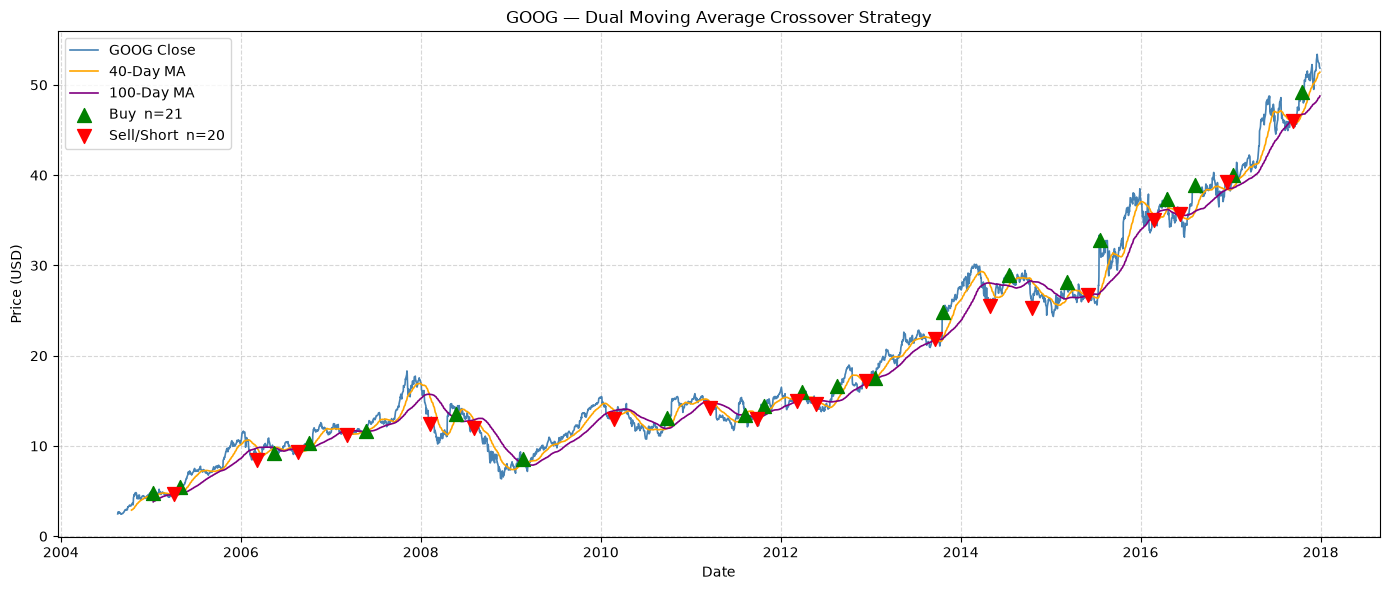

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

# Price and moving averages
ax.plot(goog_data.index, goog_data['Close'],   color='steelblue', linewidth=1.2, label='GOOG Close')
ax.plot(signals.index,   signals['short_ma'],  color='orange',    linewidth=1.2, label='40-Day MA')
ax.plot(signals.index,   signals['long_ma'],   color='purple',    linewidth=1.2, label='100-Day MA')

# Buy signals (orders > 0)
buy_dates  = signals[signals['orders'] > 0].index
# Sell/short signals (orders < 0)
sell_dates = signals[signals['orders'] < 0].index

ax.scatter(buy_dates,  goog_data.loc[buy_dates,  'Close'],
           marker='^', color='green', s=100, zorder=5, label=f'Buy  n={len(buy_dates)}')
ax.scatter(sell_dates, goog_data.loc[sell_dates, 'Close'],
           marker='v', color='red',   s=100, zorder=5, label=f'Sell/Short  n={len(sell_dates)}')

ax.set_title('GOOG — Dual Moving Average Crossover Strategy')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [6]:
INITIAL_CAPITAL = 10_000
SHARES          = 100

position = np.zeros(len(goog_data))
holdings = np.zeros(len(goog_data))
cash     = np.zeros(len(goog_data))
total    = np.zeros(len(goog_data))

cash[0]  = INITIAL_CAPITAL
total[0] = INITIAL_CAPITAL

sig   = signals['signal'].values
ord_  = signals['orders'].values
close = goog_data['Close'].values

for i in range(1, len(goog_data)):
    position[i] = sig[i] * SHARES      # +100, -100, or 0

    shares_traded = position[i] - position[i-1]

    # Cash changes by the cost of shares traded
    # Buying shares (shares_traded > 0) reduces cash
    # Selling/shorting shares (shares_traded < 0) increases cash
    cash[i] = cash[i-1] - shares_traded * close[i]

    holdings[i] = position[i] * close[i]
    total[i]    = cash[i] + holdings[i]

portfolio = pd.DataFrame({
    'position': position,
    'holdings': holdings,
    'cash':     cash,
    'total':    total
}, index=goog_data.index)

print(portfolio.tail(10))
print(f"\nFinal portfolio value: ${portfolio['total'].iloc[-1]:,.2f}")

            position     holdings         cash        total
Date                                                       
2017-12-15     100.0  5274.447250  3550.970697  8825.417948
2017-12-18     100.0  5338.630676  3550.970697  8889.601374
2017-12-19     100.0  5306.613541  3550.970697  8857.584238
2017-12-20     100.0  5278.213882  3550.970697  8829.184580
2017-12-21     100.0  5271.670151  3550.970697  8822.640848
2017-12-22     100.0  5254.274368  3550.970697  8805.245066
2017-12-26     100.0  5237.522888  3550.970697  8788.493586
2017-12-27     100.0  5200.994110  3550.970697  8751.964808
2017-12-28     100.0  5194.898224  3550.970697  8745.868921
2017-12-29     100.0  5186.274338  3550.970697  8737.245035

Final portfolio value: $8,737.25


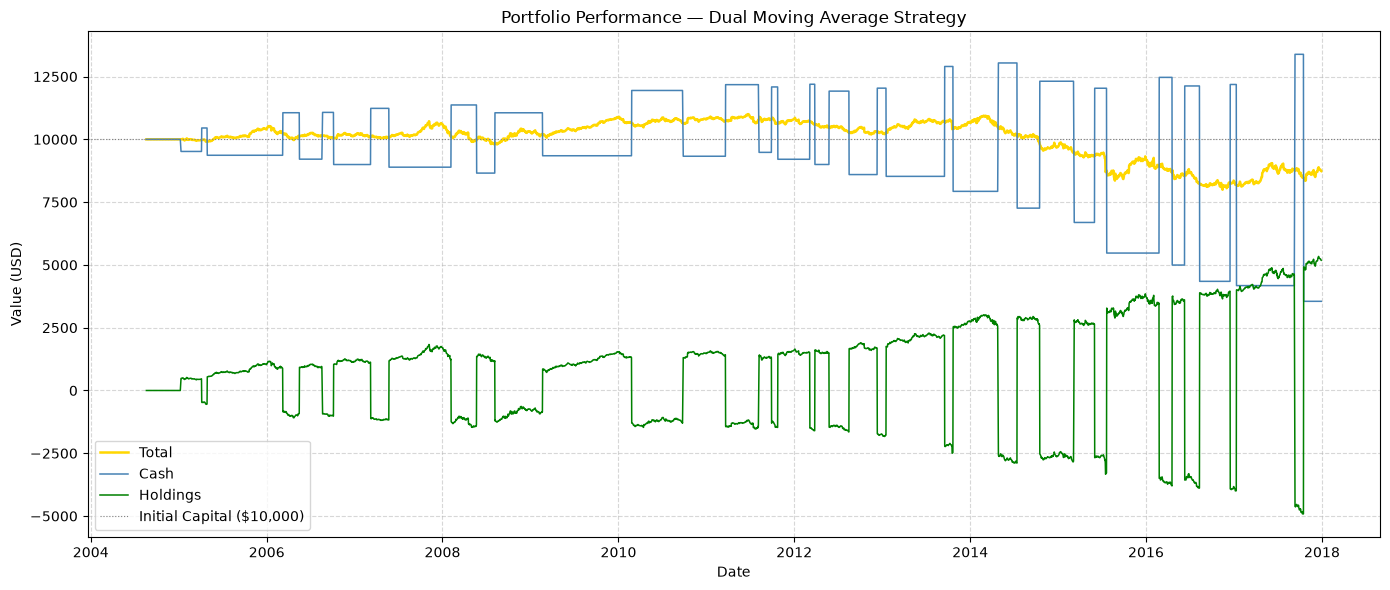

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(portfolio.index, portfolio['total'],    label='Total',    color='gold',      linewidth=1.8)
ax.plot(portfolio.index, portfolio['cash'],     label='Cash',     color='steelblue', linewidth=1.1)
ax.plot(portfolio.index, portfolio['holdings'], label='Holdings', color='green',     linewidth=1.1)
ax.axhline(INITIAL_CAPITAL, color='gray', linewidth=0.8, linestyle=':',
           label=f'Initial Capital (${INITIAL_CAPITAL:,})')

ax.set_title('Portfolio Performance — Dual Moving Average Strategy')
ax.set_ylabel('Value (USD)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()